Ejercicio Python 1: Construcción de un portafolio eficiente con simulación
Evaluar la capacidad para aplicar simulaciones Monte Carlo en la construcción y análisis de portafolios con distintos niveles de riesgo y rendimiento.

Descarga precios históricos de tres activos financieros distintos El periodo de análisis debe cubrir al menos 3 años.

Calcula los rendimientos diarios y estima sus medias y matriz de covarianzas.

Simula al menos 10,000 portafolios conformados por los tres activos, con pesos aleatorios que sumen 1.

Para cada portafolio, calcula:

Rendimiento esperado.

Riesgo (desviación estándar).

Ratio de Sharpe (considera una tasa libre de riesgo de 4% anual).

Grafica el diagrama riesgo–rendimiento con todos los portafolios. En la misma figura:

Identifica el portafolio de menor riesgo.

Identifica el portafolio de mayor rendimiento.

Identifica el portafolio con mayor Sharpe.

Redacta un breve análisis, usando markdown en tu notebook, explicando qué portafolio recomendarías y por qué.

Edgardo Noel González Tejeda

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
tickers = ["FLEX", "NVDA", "AMD"]

prices = yf.download(tickers, start="2021-01-01")["Close"]
prices

[*********************100%***********************]  3 of 3 completed


Ticker,AMD,FLEX,NVDA
Date,,,
2021-01-04,92.300003,13.474002,13.076725
2021-01-05,92.769997,13.428787,13.367157
2021-01-06,90.330002,14.069329,12.579124
2021-01-07,95.160004,14.513941,13.306580
2021-01-08,94.580002,14.295403,13.239518
...,...,...,...
2026-02-25,210.860001,65.669998,195.559998
2026-02-26,203.679993,63.209999,184.889999
2026-02-27,200.210007,63.020000,177.190002


**2. Calcula los rendimientos diarios y estima sus medias y matriz de covarianzas.**

In [3]:
returns = prices.pct_change().dropna()

mean_returns = returns.mean()
mean_returns * 100

Ticker
AMD     0.111348
FLEX    0.148534
NVDA    0.255403
dtype: float64

In [4]:
cov_matrix = returns.cov()
cov_matrix

Ticker,AMD,FLEX,NVDA
Ticker,,,
AMD,0.001114,0.000416,0.000753
FLEX,0.000416,0.000585,0.000409
NVDA,0.000753,0.000409,0.001066


Simula al menos 10,000 portafolios conformados por los tres activos, con pesos aleatorios que sumen 1.

Para cada portafolio, calcula:

Rendimiento esperado.

Riesgo (desviación estándar).

Ratio de Sharpe (considera una tasa libre de riesgo de 4% anual).

In [8]:
n = 10000
rf = 0.04

p_returns = np.zeros(n)
p_volatilities = np.zeros(n)
p_sharpes = np.zeros(n)
all_weights = np.zeros((n, len(tickers)))

for i in range(n):
    weights = np.random.random(len(tickers))
    weights /= np.sum(weights)
    all_weights[i, :] = weights
    
    port_return = np.sum(weights * mean_returns)
    
    port_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    
    sharpe_ratio = (port_return - rf) / port_volatility
    
    p_returns[i] = port_return
    p_volatilities[i] = port_volatility
    p_sharpes[i] = sharpe_ratio

In [9]:
min_vol_idx = np.argmin(p_volatilities)
max_ret_idx = np.argmax(p_returns)
max_sharpe_idx = np.argmax(p_sharpes)

print("Mejor Sharpe: Rendimiento=" + str(round(p_returns[max_sharpe_idx], 4)) + ", Riesgo=" + str(round(p_volatilities[max_sharpe_idx], 4)))
print("Menor Riesgo: Rendimiento=" + str(round(p_returns[min_vol_idx], 4)) + ", Riesgo=" + str(round(p_volatilities[min_vol_idx], 4)))
print("Mayor Rendimiento: Rendimiento=" + str(round(p_returns[max_ret_idx], 4)) + ", Riesgo=" + str(round(p_volatilities[max_ret_idx], 4)))

Mejor Sharpe: Rendimiento=0.0025, Riesgo=0.0325
Menor Riesgo: Rendimiento=0.0016, Riesgo=0.0233
Mayor Rendimiento: Rendimiento=0.0025, Riesgo=0.0325


Grafica el diagrama riesgo–rendimiento con todos los portafolios. En la misma figura:

Identifica el portafolio de menor riesgo.

Identifica el portafolio de mayor rendimiento.

Identifica el portafolio con mayor Sharpe.

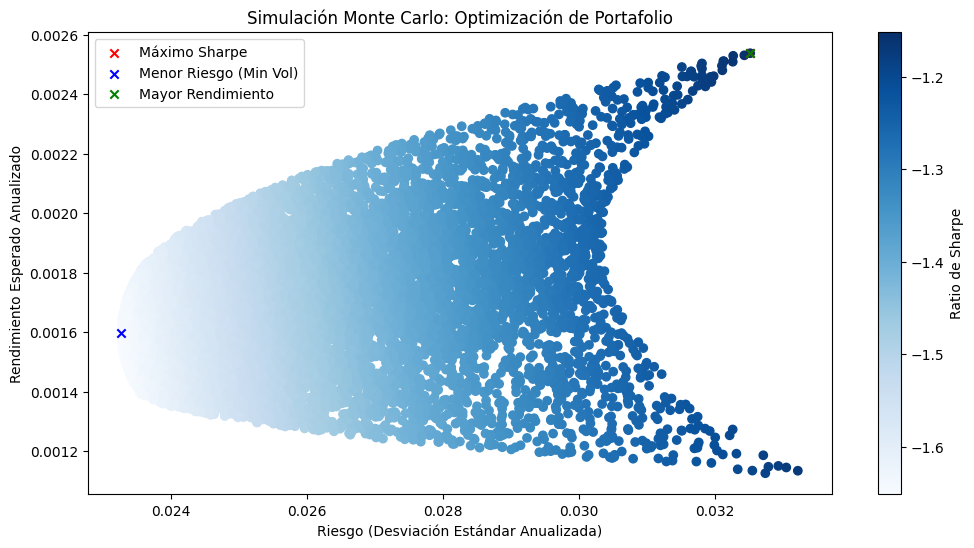

In [10]:
plt.figure(figsize=(12, 6))

plt.scatter(p_volatilities, p_returns, c=p_sharpes, cmap='Blues', marker='o')
plt.colorbar(label='Ratio de Sharpe')

plt.scatter(p_volatilities[max_sharpe_idx], p_returns[max_sharpe_idx], marker='x', color='r', label='Máximo Sharpe')

plt.scatter(p_volatilities[min_vol_idx], p_returns[min_vol_idx], marker='x', color='b', label='Menor Riesgo (Min Vol)')

plt.scatter(p_volatilities[max_ret_idx], p_returns[max_ret_idx], marker='x', color='g', label='Mayor Rendimiento')

plt.title('Simulación Monte Carlo: Optimización de Portafolio')
plt.xlabel('Riesgo (Desviación Estándar Anualizada)')
plt.ylabel('Rendimiento Esperado Anualizado')
plt.legend()
plt.show()

Redacta un breve análisis, usando markdown en tu notebook, explicando qué portafolio recomendarías y por qué.

Segun la simulación tanto el portafolio con mayor sharpe como el de mayor rendimiento, presentan el nivel de riesgo mas alto, en cambio el portafolio con menor riesgo da como resultado un rendimiento bajo aunque no tanto.

En este caso no seria muy recomendable elegir ni el de mayor sharpe ni el de mayor rendimiento. Como se ve el portafolio con menor riesgo da un retorno decente y por lo tanto es mejor opción que los otros dos.